In [1]:
#Problem 5 Setup Below

In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Problem parameters
kappa = 1.0
R = 1.0
s = 1.0

# Analytical solution from Problem 2
def T_exact(r):
    return s * (R**2 - r**2) / (4.0 * kappa)


In [4]:
# Check analytical boundary conditions
print("T(R) =", T_exact(R))
print("Analytical solution at r=0 =", T_exact(0))

T(R) = 0.0
Analytical solution at r=0 = 0.25


In [5]:
#Problem 5 Setup End/ Problem 5a Start

In [6]:
# Generate training data
r_train_np = np.linspace(0.0, R, 25).reshape(-1, 1)
T_train_np = T_exact(r_train_np)

r_train = torch.tensor(r_train_np, dtype=torch.float32)
T_train = torch.tensor(T_train_np, dtype=torch.float32)

print("Number of training points:", len(r_train))

Number of training points: 25


In [7]:
class TemperatureNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, r):
        return self.net(r)

In [8]:
model_a = TemperatureNet()

optimizer = torch.optim.Adam(
    model_a.parameters(),
    lr=0.01
)

loss_history_a = []

epochs = 5000

for epoch in range(epochs):

    T_pred = model_a(r_train)

    # Mean squared error
    loss = torch.mean((T_pred - T_train)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history_a.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6e}")

Epoch 0: Loss = 1.578538e-01
Epoch 500: Loss = 5.736538e-06
Epoch 1000: Loss = 4.347012e-07
Epoch 1500: Loss = 3.106267e-07
Epoch 2000: Loss = 2.433728e-07
Epoch 2500: Loss = 2.116972e-07
Epoch 3000: Loss = 2.631522e-07
Epoch 3500: Loss = 1.139079e-06
Epoch 4000: Loss = 3.792300e-05
Epoch 4500: Loss = 2.860664e-07


In [9]:
# Dense grid for evaluation
r_dense_np = np.linspace(0.0, R, 200).reshape(-1, 1)
r_dense = torch.tensor(r_dense_np, dtype=torch.float32)

with torch.no_grad():
    T_pred_a = model_a(r_dense).numpy()

T_exact_dense = T_exact(r_dense_np)

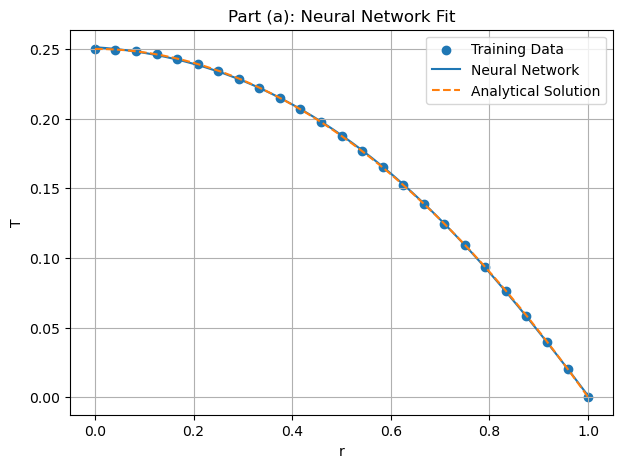

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    r_train_np,
    T_train_np,
    label="Training Data"
)

plt.plot(
    r_dense_np,
    T_pred_a,
    label="Neural Network"
)

plt.plot(
    r_dense_np,
    T_exact_dense,
    "--",
    label="Analytical Solution"
)

plt.xlabel("r")
plt.ylabel("T")
plt.title("Part (a): Neural Network Fit")
plt.legend()
plt.grid()
plt.show()

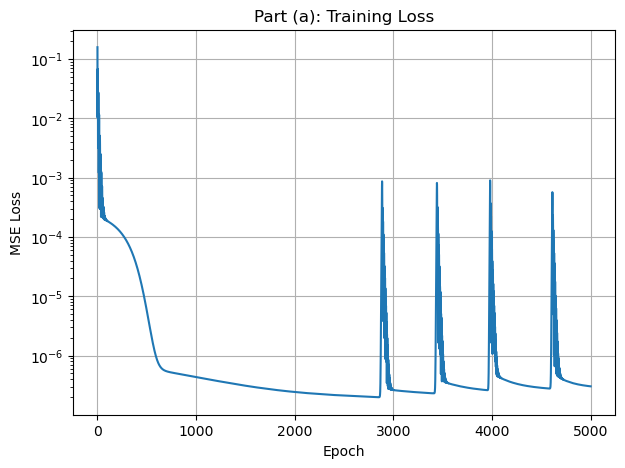

In [11]:
plt.figure(figsize=(7, 5))

plt.semilogy(loss_history_a)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Part (a): Training Loss")
plt.grid()
plt.show()

In [12]:
error_a = (
    np.linalg.norm(T_pred_a - T_exact_dense)
    / np.linalg.norm(T_exact_dense)
)

max_error_a = np.max(
    np.abs(T_pred_a - T_exact_dense)
)

print("Part (a) Relative L2 Error =", error_a)
print("Part (a) Maximum Absolute Error =", max_error_a)

Part (a) Relative L2 Error = 0.0027517253221240106
Part (a) Maximum Absolute Error = 0.0012096762657165527


In [13]:
#Problem 5a End/ Problem 5b Start

In [14]:
def derivative(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

In [15]:
model_b = TemperatureNet()

optimizer_b = torch.optim.Adam(
    model_b.parameters(),
    lr=0.01
)

# Interior collocation points
r_col = torch.linspace(
    0.0,
    R,
    100
).reshape(-1, 1)

r_col.requires_grad_(True)

loss_history_b = []


In [16]:
epochs = 10000

for epoch in range(epochs):

    # --------------------------------
    # PDE residual
    # --------------------------------

    T = model_b(r_col)

    dTdr = derivative(T, r_col)

    r_dTdr = r_col * dTdr

    residual = (
        kappa * derivative(r_dTdr, r_col)
        + r_col * s
    )

    loss_pde = torch.mean(residual**2)

    # --------------------------------
    # Boundary condition at r = 0
    # dT/dr = 0
    # --------------------------------

    r0 = torch.tensor(
        [[0.0]],
        dtype=torch.float32,
        requires_grad=True
    )

    T0 = model_b(r0)

    dTdr0 = derivative(T0, r0)

    loss_bc0 = torch.mean(dTdr0**2)

    # --------------------------------
    # Boundary condition at r = R
    # T(R) = 0
    # --------------------------------

    rR = torch.tensor(
        [[R]],
        dtype=torch.float32
    )

    TR = model_b(rR)

    loss_bcR = torch.mean(TR**2)

    # --------------------------------
    # Total loss
    # --------------------------------

    loss = loss_pde + loss_bc0 + loss_bcR

    optimizer_b.zero_grad()
    loss.backward()
    optimizer_b.step()

    loss_history_b.append(loss.item())

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch}: "
            f"Total = {loss.item():.6e}, "
            f"PDE = {loss_pde.item():.6e}, "
            f"BC0 = {loss_bc0.item():.6e}, "
            f"BCR = {loss_bcR.item():.6e}"
        )

Epoch 0: Total = 3.338762e-01, PDE = 2.552708e-01, BC0 = 7.461789e-02, BCR = 3.987552e-03
Epoch 1000: Total = 2.540525e-06, PDE = 2.478565e-06, BC0 = 1.436604e-08, BCR = 4.759398e-08
Epoch 2000: Total = 1.553322e-06, PDE = 1.529082e-06, BC0 = 2.423855e-08, BCR = 8.262280e-13
Epoch 3000: Total = 2.223128e-06, PDE = 2.053412e-06, BC0 = 1.689724e-07, BCR = 7.436052e-10
Epoch 4000: Total = 5.113181e-07, PDE = 5.045685e-07, BC0 = 6.739767e-09, BCR = 9.838852e-12
Epoch 5000: Total = 4.363361e-07, PDE = 3.982576e-07, BC0 = 2.309897e-08, BCR = 1.497948e-08
Epoch 6000: Total = 1.962999e-05, PDE = 9.364342e-07, BC0 = 1.528859e-06, BCR = 1.716469e-05
Epoch 7000: Total = 2.922085e-06, PDE = 1.550853e-06, BC0 = 8.232001e-09, BCR = 1.363001e-06
Epoch 8000: Total = 1.268679e-07, PDE = 1.248916e-07, BC0 = 1.975817e-09, BCR = 4.698464e-13
Epoch 9000: Total = 3.591653e-08, PDE = 3.574311e-08, BC0 = 1.733709e-10, BCR = 4.352074e-14


In [17]:
with torch.no_grad():
    T_pred_b = model_b(r_dense).numpy()

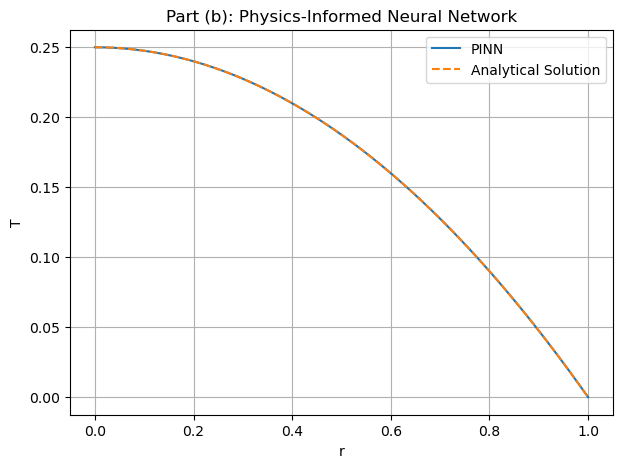

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(
    r_dense_np,
    T_pred_b,
    label="PINN"
)

plt.plot(
    r_dense_np,
    T_exact_dense,
    "--",
    label="Analytical Solution"
)

plt.xlabel("r")
plt.ylabel("T")
plt.title("Part (b): Physics-Informed Neural Network")
plt.legend()
plt.grid()
plt.show()

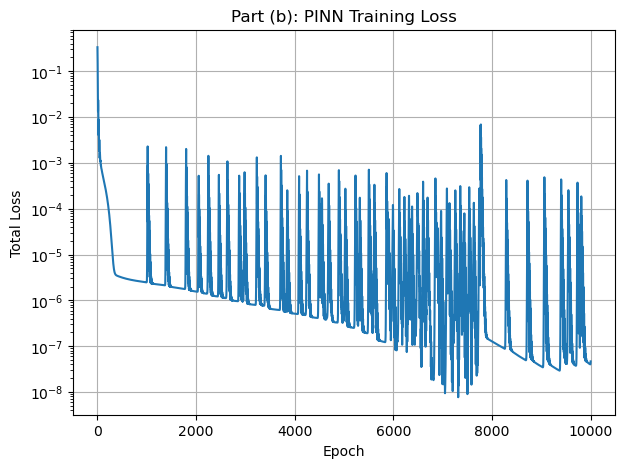

In [19]:
plt.figure(figsize=(7, 5))

plt.semilogy(loss_history_b)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Part (b): PINN Training Loss")
plt.grid()
plt.show()

In [20]:
# Center BC
r0_check = torch.tensor(
    [[0.0]],
    dtype=torch.float32,
    requires_grad=True
)

T0_check = model_b(r0_check)

dTdr0_check = derivative(
    T0_check,
    r0_check
)

# Outer BC
rR_check = torch.tensor(
    [[R]],
    dtype=torch.float32
)

TR_check = model_b(rR_check)

print("T(R) =", TR_check.item())
print("dT/dr at r=0 =", dTdr0_check.item())

T(R) = -9.760260581970215e-05
dT/dr at r=0 = -2.0478852093219757e-05


In [21]:
r_res = torch.linspace(
    0.0,
    R,
    200
).reshape(-1, 1)

r_res.requires_grad_(True)

residual_final = pinn_residual = (
    kappa * derivative(
        r_res * derivative(model_b(r_res), r_res),
        r_res
    )
    + r_res * s
)

print(
    "Maximum absolute PDE residual =",
    torch.max(torch.abs(residual_final)).item()
)

Maximum absolute PDE residual = 0.0003554821014404297


In [22]:
error_b = (
    np.linalg.norm(T_pred_b - T_exact_dense)
    / np.linalg.norm(T_exact_dense)
)

max_error_b = np.max(
    np.abs(T_pred_b - T_exact_dense)
)

print("Part (b) Relative L2 Error =", error_b)
print("Part (b) Maximum Absolute Error =", max_error_b)

Part (b) Relative L2 Error = 0.0004041664020632606
Part (b) Maximum Absolute Error = 9.759515523910522e-05


In [23]:
#Problem 5b End/Problem 5c Start

In [24]:
with torch.no_grad():
    T_pred_b = model_b(r_dense).detach().numpy()

print("Prediction successful!")
print(T_pred_b[:5])

Prediction successful!
[[0.24995482]
 [0.24994844]
 [0.24992949]
 [0.24989796]
 [0.24985391]]


In [25]:
def finite_difference(N):

    # Create grid
    r = np.linspace(0.0, R, N + 1)

    # Grid spacing
    dr = r[1] - r[0]

    # Create matrix and right-hand side
    A = np.zeros((N + 1, N + 1))
    b = np.zeros(N + 1)

    # ------------------------------------------------
    # Boundary condition at r = 0:
    #
    # dT/dr = 0
    #
    # Using second-order forward difference:
    #
    # (-3T0 + 4T1 - T2)/(2 dr) = 0
    # ------------------------------------------------

    A[0, 0] = -3.0
    A[0, 1] = 4.0
    A[0, 2] = -1.0

    # ------------------------------------------------
    # Interior nodes
    #
    # kappa [ r T'' + T' ] + r s = 0
    #
    # T'' = (Ti+1 - 2Ti + Ti-1)/dr^2
    #
    # T' = (Ti+1 - Ti-1)/(2dr)
    # ------------------------------------------------

    for i in range(1, N):

        ri = r[i]

        A[i, i-1] = kappa * (
            ri / dr**2 - 1.0 / (2.0 * dr)
        )

        A[i, i] = kappa * (
            -2.0 * ri / dr**2
        )

        A[i, i+1] = kappa * (
            ri / dr**2 + 1.0 / (2.0 * dr)
        )

        b[i] = -ri * s

    # ------------------------------------------------
    # Boundary condition at r = R:
    #
    # T(R) = 0
    # ------------------------------------------------

    A[N, N] = 1.0
    b[N] = 0.0

    # Solve A*T = b
    T_fd = np.linalg.solve(A, b)

    return r, T_fd

In [26]:
N = 40

r_fd, T_fd = finite_difference(N)

T_exact_fd = T_exact(r_fd)

print("Grid spacing =", R / N)
print("T(0) =", T_fd[0])
print("T(R) =", T_fd[-1])

Grid spacing = 0.025
T(0) = 0.2500000000000021
T(R) = 0.0


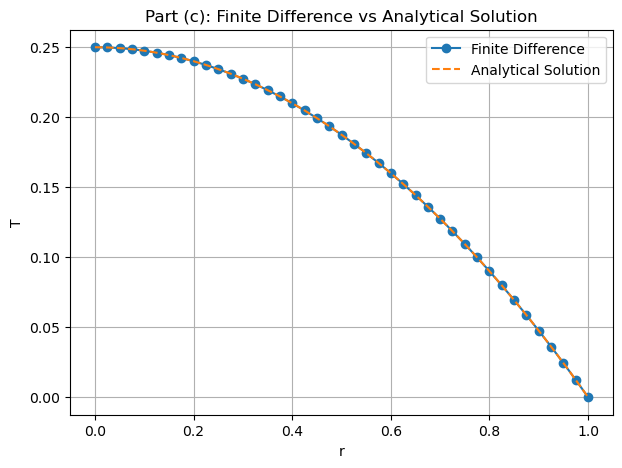

In [27]:
plt.figure(figsize=(7, 5))

plt.plot(
    r_fd,
    T_fd,
    "o-",
    label="Finite Difference"
)

plt.plot(
    r_dense_np,
    T_exact_dense,
    "--",
    label="Analytical Solution"
)

plt.xlabel("r")
plt.ylabel("T")
plt.title("Part (c): Finite Difference vs Analytical Solution")
plt.legend()
plt.grid()
plt.show()

In [28]:
N_values = [10, 20, 40, 80]

fd_errors = []
dr_values = []

for N in N_values:

    r_fd, T_fd = finite_difference(N)

    T_exact_fd = T_exact(r_fd)

    # Relative L2 error
    error = (
        np.linalg.norm(T_fd - T_exact_fd)
        / np.linalg.norm(T_exact_fd)
    )

    dr = R / N

    dr_values.append(dr)
    fd_errors.append(error)

    print(
        f"N = {N:3d}, "
        f"dr = {dr:.5f}, "
        f"Relative L2 Error = {error:.6e}"
    )

N =  10, dr = 0.10000, Relative L2 Error = 9.867683e-16
N =  20, dr = 0.05000, Relative L2 Error = 7.128236e-15
N =  40, dr = 0.02500, Relative L2 Error = 4.857996e-15
N =  80, dr = 0.01250, Relative L2 Error = 6.622670e-14


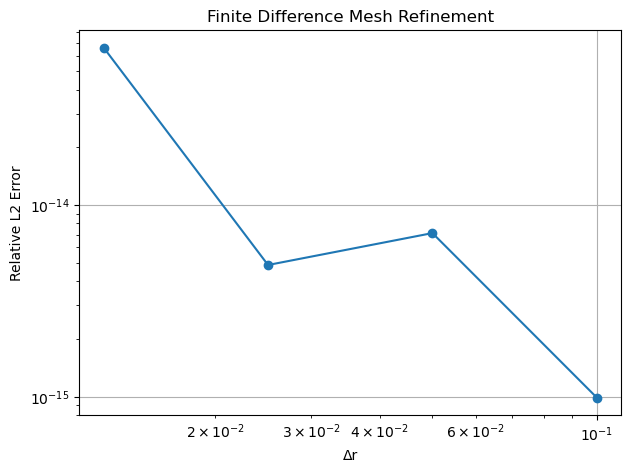

In [29]:
plt.figure(figsize=(7, 5))

plt.loglog(
    dr_values,
    fd_errors,
    "o-"
)

plt.xlabel("Δr")
plt.ylabel("Relative L2 Error")
plt.title("Finite Difference Mesh Refinement")
plt.grid()
plt.show()

In [ ]:
#Problem 5c End/ Problem 5 Final Graph

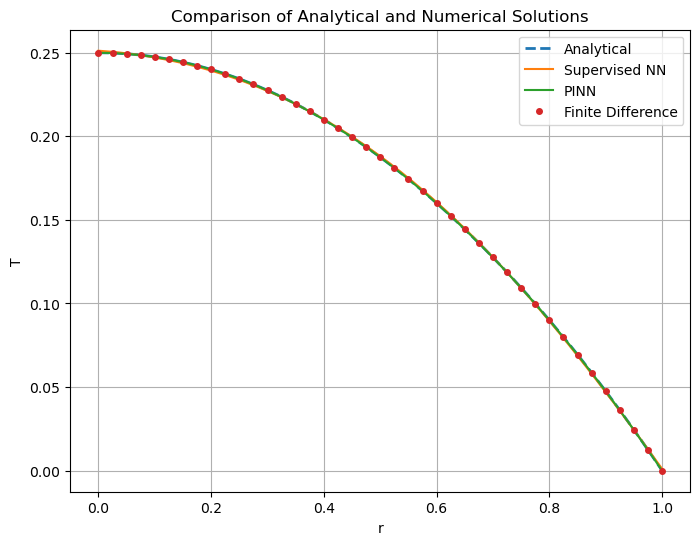

Relative L2 Errors
-----------------------------
Supervised NN : 2.751725e-03
PINN          : 4.041664e-04
Finite Diff.  : 4.857996e-15


In [30]:
# -----------------------------------------
# Final comparison of all four methods
# -----------------------------------------

# Finite difference solution using N = 40
r_fd, T_fd = finite_difference(40)

# Exact solution at finite-difference points
T_exact_fd = T_exact(r_fd)

# Calculate relative L2 errors
error_a = (
    np.linalg.norm(T_pred_a - T_exact_dense)
    / np.linalg.norm(T_exact_dense)
)

error_b = (
    np.linalg.norm(T_pred_b - T_exact_dense)
    / np.linalg.norm(T_exact_dense)
)

error_c = (
    np.linalg.norm(T_fd - T_exact_fd)
    / np.linalg.norm(T_exact_fd)
)

# -----------------------------------------
# Plot all solutions
# -----------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    r_dense_np,
    T_exact_dense,
    "--",
    linewidth=2,
    label="Analytical"
)

plt.plot(
    r_dense_np,
    T_pred_a,
    label="Supervised NN"
)

plt.plot(
    r_dense_np,
    T_pred_b,
    label="PINN"
)

plt.plot(
    r_fd,
    T_fd,
    "o",
    markersize=4,
    label="Finite Difference"
)

plt.xlabel("r")
plt.ylabel("T")
plt.title("Comparison of Analytical and Numerical Solutions")
plt.legend()
plt.grid()
plt.show()

# -----------------------------------------
# Print errors
# -----------------------------------------

print("Relative L2 Errors")
print("-----------------------------")
print(f"Supervised NN : {error_a:.6e}")
print(f"PINN          : {error_b:.6e}")
print(f"Finite Diff.  : {error_c:.6e}")